## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 09 · Borough demand atlas at LSOA level, validation and stochastic demand curves

The council's statistics are LSOA statistics, so the *demand model* of EnerMap is reported, calibrated and
validated at LSOA level (the whole authority):

1. the calibrated baseline: delivered gas and electricity per meter against DESNZ 2021,
   error maps (NMBE per LSOA), intensity and heating-system maps - every map drawn on all
   building footprints (non-residential in grey) with the study-area wards outlined;
2. validation: in-sample fit, the out-of-fold transfer test of notebook 07 and the evidence-vintage
   split (certificate inside the benchmark window / later certificate / synthesised record);
3. demand curves from the stochastic households: hourly heat demand of the stock with a
   fan of household realisations, winter average days by heating pattern, load-duration
   curves and the within-archetype spread of annual intensity.

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import config as CFG
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
from ukubem.calibrate import (ArchetypeCalibrator, PHYS_BOUNDS, POST_FIXED, make_representatives, _stock_delivered, evaluate_on)
from ukubem import metrics as M, maps, profiles, measures, stock
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


In [2]:
theta = json.load(open(UBEM_OUT / "06_calibrated_theta.json")); phys, post = theta["physics"], theta["post"]
inputs0 = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
labels = pd.read_parquet(TABLE_LABELS)
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
inputs, reps = make_representatives(inputs0)
folds = pd.read_csv(CV_FOLDS)
A_cal = UKGeometryAssumptions().with_(wall_u_scale=phys["wall_u_scale"], roof_u_scale=phys["roof_u_scale"], window_u_scale=phys["window_u_scale"],
                                      infil_scale=phys["infil_scale"], gains_scale=phys["gains_scale"], setpoint_offset_c=phys["setpoint_offset_c"],
                                      stochastic_setback_c=phys.get("setback_c", 12.0))
inten_cal = pd.read_csv(UBEM_OUT / "06_archetype_intensities_calibrated.csv", index_col=0)
stock_cal = pd.read_parquet(UBEM_OUT / "06_stock_calibrated.parquet")
print(f"{len(inputs):,} dwellings, {len(reps)} representatives, {folds['fold'].nunique()} spatial folds; calibrated physics {phys}")

57,300 dwellings, 102 representatives, 7 spatial folds; calibrated physics {'wall_u_scale': 1.0652602409167062, 'roof_u_scale': 1.1248578219743166, 'window_u_scale': 1.25, 'infil_scale': 0.8129959823081263, 'gains_scale': 0.8155295436843902, 'setpoint_offset_c': 1.0, 'setback_c': 15.691329877128062}


In [3]:
L = maps.load_layers(CFG, town_only=False)
L["buildings"] = L["buildings"]          # authority-wide footprints for the LSOA maps (58,630 polygons)
st = stock_cal.set_index("dwelling_id").join(inputs[["LSOA", "ward", "in_study_area", "toid", "heat_system", "evidence_vintage", "in_calibration_population", "construction_sa"]])
t = aggregate_lsoa(stock_cal, labels, bench_lsoa); m_in = mape(t)
t["gas_nmbe_pct"] = 100 * (t["sim_gas_mean_kWh"] - t["gas_mean_kWh"]) / t["gas_mean_kWh"]
t["elec_nmbe_pct"] = 100 * (t["sim_elec_mean_kWh"] - t["elec_mean_kWh"]) / t["elec_mean_kWh"]
t["Q_H_kWh_m2"] = st.groupby("LSOA")["Q_H_kWh_m2"].mean()
t["hp_share_pct"] = 100 * st.groupby("LSOA")["systems_fam"].apply(lambda s: s.eq("S.HeatPump").mean())
t["elec_heat_share_pct"] = 100 * st.groupby("LSOA")["systems_fam"].apply(lambda s: s.isin(["S.ElecResistive", "S.ElecStorage", "S.HeatPump"]).mean())
t["gas_GWh"] = st.groupby("LSOA")["delivered_gas_kWh"].sum() / 1e6; t["elec_GWh"] = st.groupby("LSOA")["delivered_elec_kWh"].sum() / 1e6
t.to_csv(UBEM_OUT / "09_lsoa_atlas.csv")
print("in-sample LSOA metrics:", {k: round(v, 2) for k, v in m_in.items() if "WAPE" in k or "NMBE" in k or "R2" in k})
print(f"authority totals (all 57,300): gas {t['gas_GWh'].sum():.0f} GWh vs DESNZ {bench_lsoa['gas_total_kWh'].sum()/1e6:.0f} GWh (meters);  elec {t['elec_GWh'].sum():.0f} GWh vs {bench_lsoa['elec_total_kWh'].sum()/1e6:.0f} GWh")

in-sample LSOA metrics: {'gas_WAPE_pct': 6.54, 'elec_WAPE_pct': 10.92, 'gas_NMBE_pct': -2.06, 'elec_NMBE_pct': 1.85, 'gas_R2_predictive': 0.91, 'elec_R2_predictive': 0.72}
authority totals (all 57,300): gas 745 GWh vs DESNZ 816 GWh (meters);  elec 248 GWh vs 250 GWh


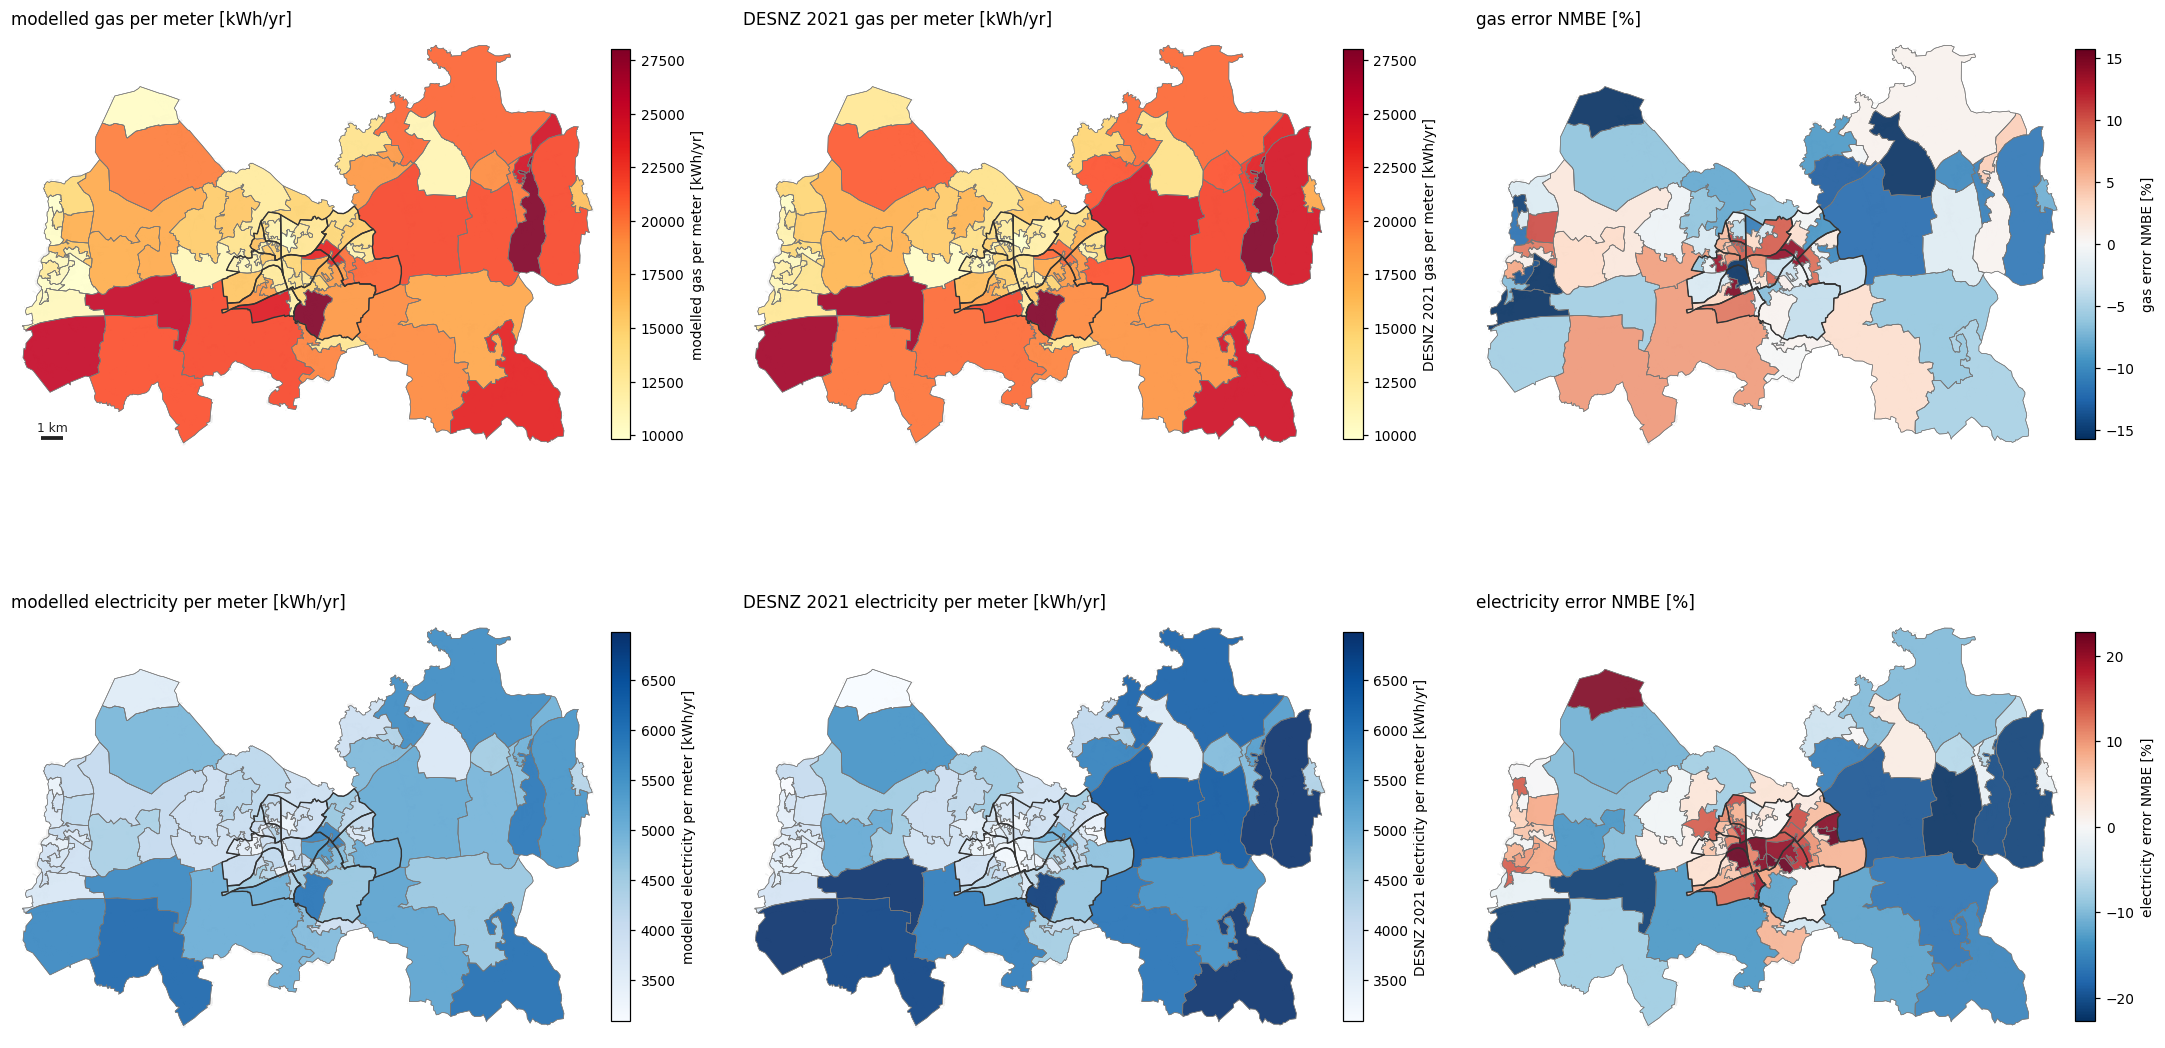

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
panels = [("sim_gas_mean_kWh", "modelled gas per meter [kWh/yr]", maps.SEQ), ("gas_mean_kWh", "DESNZ 2021 gas per meter [kWh/yr]", maps.SEQ),
          ("gas_nmbe_pct", "gas error NMBE [%]", maps.DIV), ("sim_elec_mean_kWh", "modelled electricity per meter [kWh/yr]", maps.SEQ_BLUE),
          ("elec_mean_kWh", "DESNZ 2021 electricity per meter [kWh/yr]", maps.SEQ_BLUE), ("elec_nmbe_pct", "electricity error NMBE [%]", maps.DIV)]
for ax, (col, lab, cmap) in zip(axes.ravel(), panels):
    maps.base_map(ax, L, extent="borough", show_nonres=False)
    v = t[col]
    if "nmbe" in col:
        lim = float(np.nanpercentile(v.abs(), 95)); maps.lsoa_map(ax, L, v, cmap=cmap, label=lab, vmin=-lim, vmax=lim)
    else:
        base_col = col.replace("sim_", ""); shared = t[[base_col, "sim_" + base_col]]
        maps.lsoa_map(ax, L, v, cmap=cmap, label=lab, vmin=float(np.nanpercentile(shared.values, 2)), vmax=float(np.nanpercentile(shared.values, 98)))
    maps.finish(ax, L, title=lab, labels=False, bar=(col == "sim_gas_mean_kWh"))
plt.tight_layout(); fig.savefig(FIG_UBEM / "09_atlas_lsoa_fit.png", bbox_inches="tight"); plt.show()

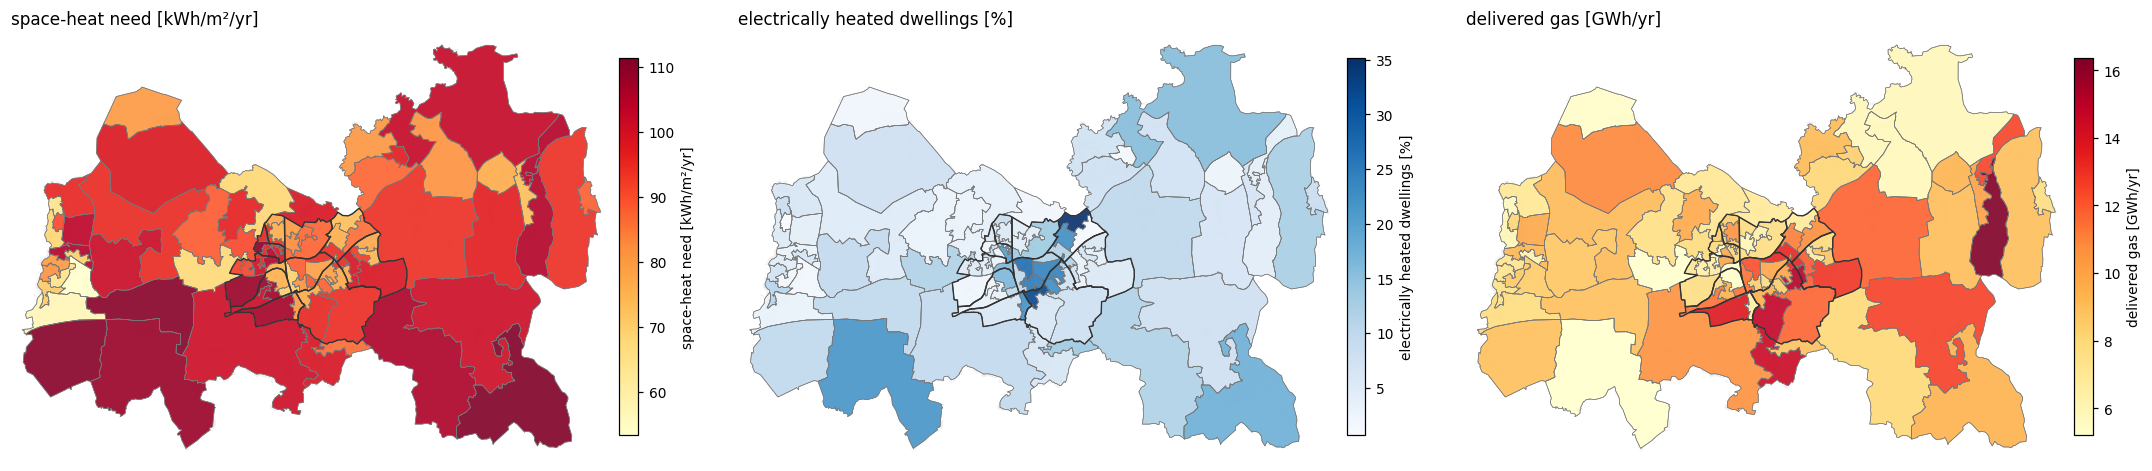

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
for ax, (col, lab, cmap) in zip(axes, [("Q_H_kWh_m2", "space-heat need [kWh/m²/yr]", maps.SEQ), ("elec_heat_share_pct", "electrically heated dwellings [%]", maps.SEQ_BLUE), ("gas_GWh", "delivered gas [GWh/yr]", maps.SEQ)]):
    maps.base_map(ax, L, extent="borough", show_nonres=False); maps.lsoa_map(ax, L, t[col], cmap=cmap, label=lab); maps.finish(ax, L, title=lab, labels=False, bar=False)
plt.tight_layout(); fig.savefig(FIG_UBEM / "09_atlas_lsoa_demand.png", bbox_inches="tight"); plt.show()

## 2 · Validation: in-sample, out-of-fold, evidence vintage

In [6]:
rows = {"in-sample (84 LSOAs, fitted)": {k: m_in[k] for k in ("gas_WAPE_pct", "gas_NMBE_pct", "gas_R2_predictive", "elec_WAPE_pct", "elec_NMBE_pct", "elec_R2_predictive")}}
if (UBEM_OUT / "07_cv_summary.json").exists():
    cvs = json.load(open(UBEM_OUT / "07_cv_summary.json")); rows["out-of-fold (7 spatial bands, nb07)"] = cvs["pooled_out_of_fold"]
# evidence vintage: which part of the stock carries the error?
for vint, sub in st.groupby("evidence_vintage"):
    tt = aggregate_lsoa(sub.reset_index()[list(stock_cal.columns)], labels, bench_lsoa); mm = mape(tt)
    rows[f"stock subset: {vint} ({len(sub):,} dwellings) vs the same LSOA means"] = {k: mm[k] for k in ("gas_WAPE_pct", "gas_NMBE_pct", "elec_WAPE_pct", "elec_NMBE_pct")}
val = pd.DataFrame(rows).T; val.to_csv(UBEM_OUT / "09_validation_table.csv")
val.round(2)

,gas_WAPE_pct,gas_NMBE_pct,gas_R2_predictive,elec_WAPE_pct,elec_NMBE_pct,elec_R2_predictive
"in-sample (84 LSOAs, fitted)",6.54,-2.06,0.91,10.92,1.85,0.72
"out-of-fold (7 spatial bands, nb07)",6.73,-2.01,0.91,10.98,1.85,0.71
"stock subset: in_window (30,384 dwellings) vs the same LSOA means",10.87,-9.16,NaN,9.22,-1.61,NaN
"stock subset: post_window (10,423 dwellings) vs the same LSOA means",12.92,-8.66,NaN,10.73,-2.55,NaN
"stock subset: synthetic (16,493 dwellings) vs the same LSOA means",19.77,16.76,NaN,19.74,11.84,NaN


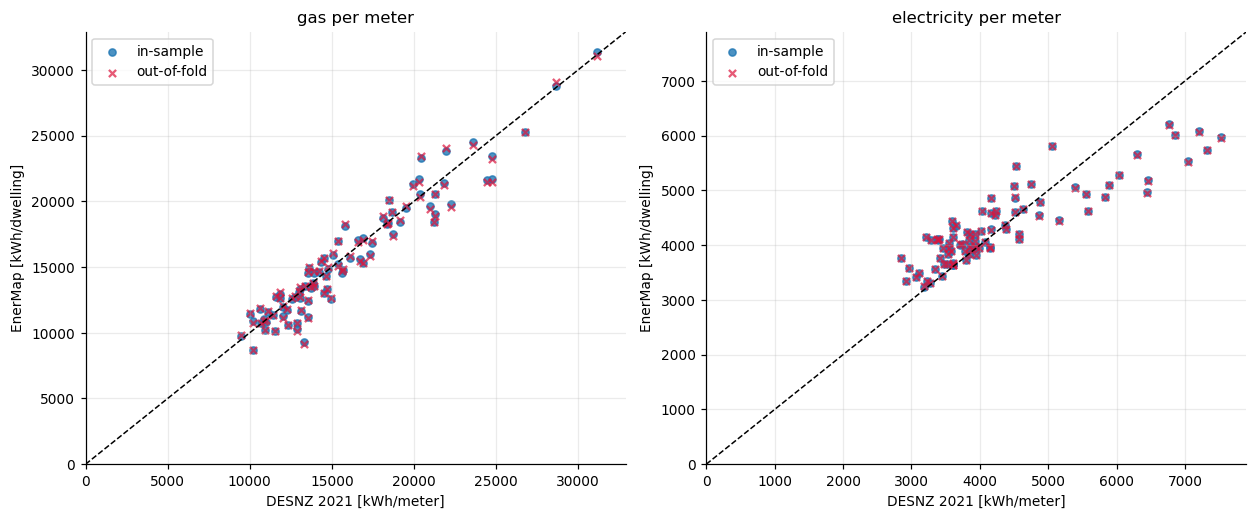

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, (sim, obs, ttl) in zip(axes, [("sim_gas_mean_kWh", "gas_mean_kWh", "gas per meter"), ("sim_elec_mean_kWh", "elec_mean_kWh", "electricity per meter")]):
    ax.scatter(t[obs], t[sim], s=22, alpha=0.8, label="in-sample")
    if (UBEM_OUT / "07_cv_lsoa_predictions.csv").exists():
        oof = pd.read_csv(UBEM_OUT / "07_cv_lsoa_predictions.csv", index_col=0); ax.scatter(oof[obs], oof[sim], s=22, alpha=0.7, marker="x", color="crimson", label="out-of-fold")
    lim = [0, max(t[obs].max(), t[sim].max()) * 1.05]; ax.plot(lim, lim, "k--", lw=1); ax.set_xlim(lim); ax.set_ylim(lim); ax.set_xlabel("DESNZ 2021 [kWh/meter]"); ax.set_ylabel("EnerMap [kWh/dwelling]"); ax.set_title(ttl); ax.legend()
plt.tight_layout(); fig.savefig(FIG_UBEM / "09_validation_scatter.png", bbox_inches="tight"); plt.show()

## 3 · Demand curves from the stochastic households

The representatives (38 construction sub-archetypes × 3 size classes) are re-simulated with
`N_REAL_H` independent household draws each, keeping the hourly heat output. The stock
profile is the *time-aligned sum* (no diversity factor) of every dwelling's
representative profile per m², scaled by its floor area; the fan comes from re-drawing which
realisation each dwelling gets (bootstrap over household draws).

In [8]:
from joblib import Parallel, delayed
N_REAL_H = 3
rows_rep = inputs.loc[reps["dwelling_id"].to_numpy()]
key = reps.set_index("dwelling_id")[["construction_sa", "size_class"]]
hourly_file = UBEM_OUT / "09_representative_hourly.npz"
if hourly_file.exists():
    z = np.load(hourly_file, allow_pickle=True); Q = z["Q_W"]; meta = pd.DataFrame(z["meta"], columns=["dwelling_id", "realisation", "construction_sa", "size_class", "heating_pattern", "A_floor"])
else:
    t0 = time.time()
    tasks = [(rows_rep.iloc[i:i + 1], SEED, k) for k in range(N_REAL_H) for i in range(len(rows_rep))]     # stratified draws, as the calibration
    res = Parallel(n_jobs=N_JOBS, batch_size=1)(delayed(simulate_rows)(c, str(EPW), str(PBE_SRC), A_cal, True, s, 2021, post, True, 60, k, N_REAL_H) for c, s, k in tasks)
    Q, meta = [], []
    for (c, s, k), r in zip(tasks, res):
        r = r[0]
        if "hourly_Q_HC_W" in r:
            Q.append(np.clip(np.asarray(r["hourly_Q_HC_W"], np.float32), 0, None)); did = int(r["dwelling_id"])
            meta.append([did, k, key.loc[did, "construction_sa"], key.loc[did, "size_class"], r.get("heating_pattern"), r["A_floor"]])
    Q = np.stack(Q); meta = pd.DataFrame(meta, columns=["dwelling_id", "realisation", "construction_sa", "size_class", "heating_pattern", "A_floor"])
    np.savez(hourly_file, Q_W=Q, meta=meta.to_numpy(dtype=object)); print(f"{len(Q)} representative-years in {(time.time()-t0)/60:.1f} min")
meta["A_floor"] = meta["A_floor"].astype(float); meta["realisation"] = meta["realisation"].astype(int)
Qm2 = Q / meta["A_floor"].to_numpy()[:, None]                   # W per m2 of the representative
idx = pd.date_range("2021-01-01", periods=8760, freq="h"); wx = profiles.epw_hourly(EPW)
print("hourly heat profiles:", Q.shape, "| annual kWh/m2 mean", round(float(Qm2.mean(axis=1).mean() * 8760 / 1000), 1))

hourly heat profiles: (306, 8760) | annual kWh/m2 mean 104.3


stock heat peak (boiler output, all 57,300): {'peak_kW': 413220.5, 'peak_time': '2021-12-13 07:00:00', 'peak_hour': 7, 'peak_month': 12, 'p99_kW': 298313.8, 'p95_kW': 227996.1, 'mean_kW': 67067.7, 'load_factor': 0.2, 'top50_hour_mode': 7}


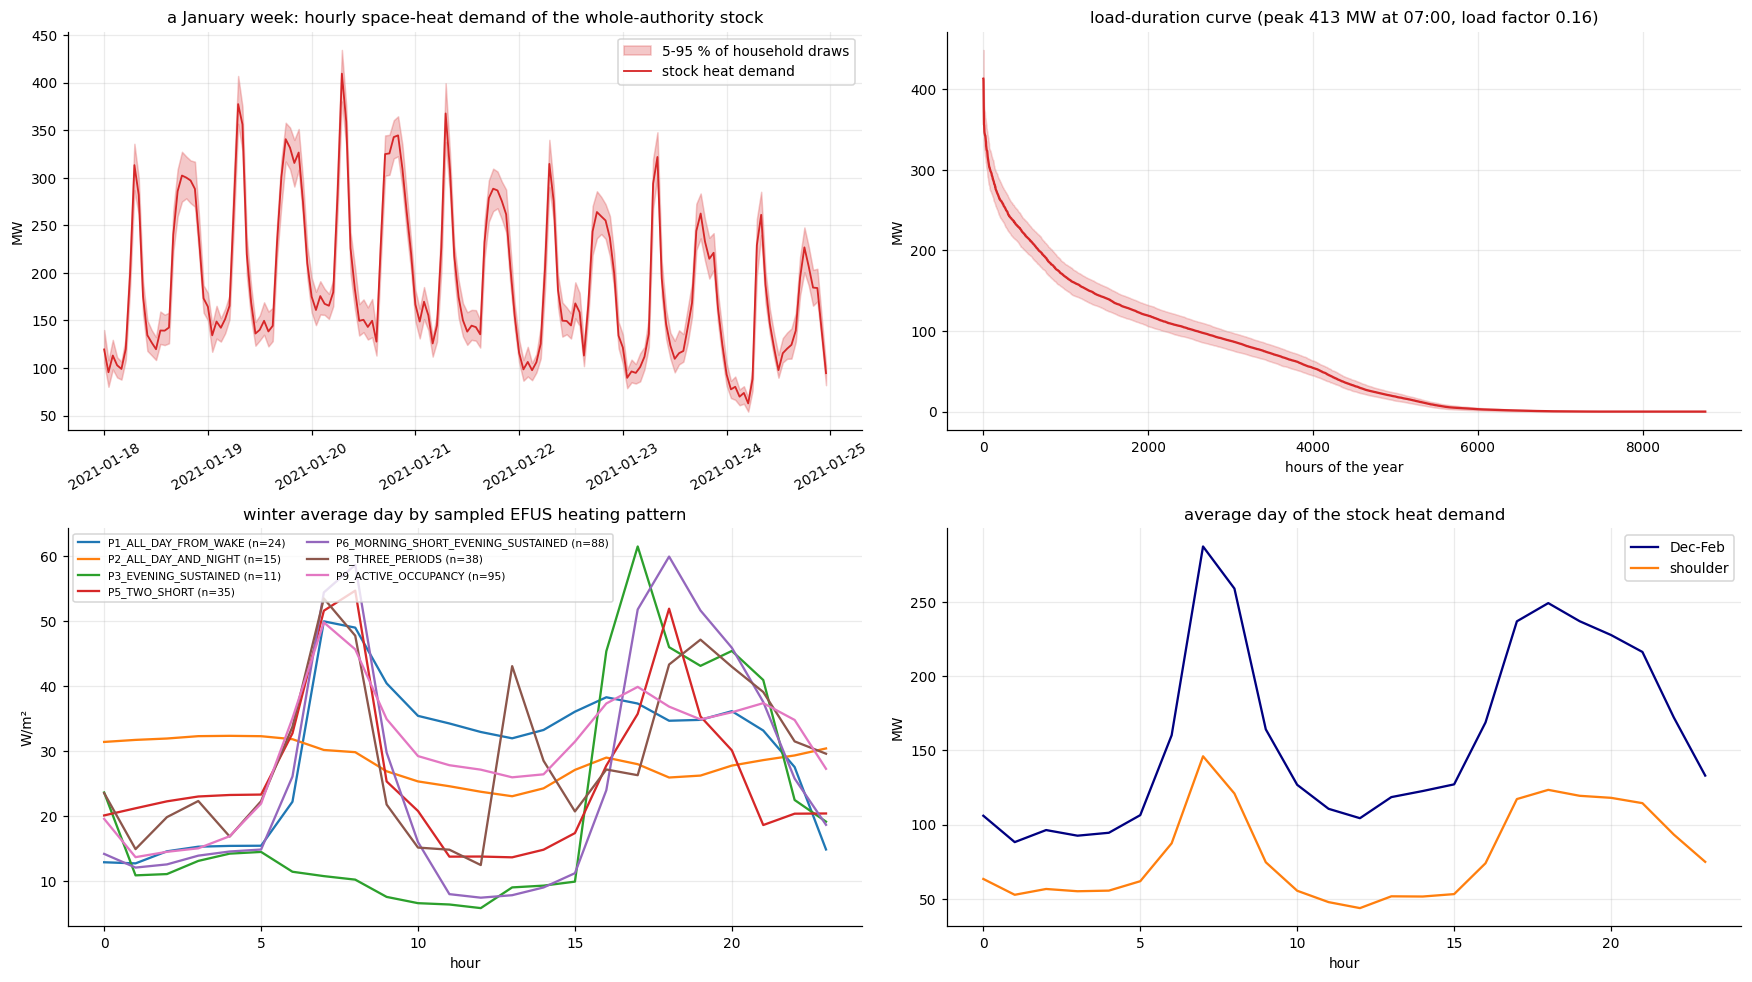

In [9]:
# stock profile: each dwelling takes the mean-over-realisations profile of its (archetype, size) per m2, times its floor area
grp = meta.groupby(["construction_sa", "size_class"]).indices
dw = inputs[["construction_sa", "size_class", "floor_area_final", "in_study_area", "ward", "LSOA"]].copy()
area_by_grp = dw.groupby(["construction_sa", "size_class"])["floor_area_final"].sum()
def stock_profile(sel=None, rng=None):
    tot = np.zeros(8760)
    for g, ii in grp.items():
        A = area_by_grp.get(g, 0.0) if sel is None else sel.get(g, 0.0)
        if A <= 0: continue
        prof = Qm2[ii].mean(axis=0) if rng is None else Qm2[rng.choice(ii, size=len(ii), replace=True)].mean(axis=0)
        tot += prof * A
    return tot / 1e6                                                 # MW
P0 = stock_profile()
rng = np.random.default_rng(SEED); fan = np.stack([stock_profile(rng=rng) for _ in range(60)])
lo, hi = np.percentile(fan, 5, axis=0), np.percentile(fan, 95, axis=0)
stats = profiles.peak_stats(P0 * 1000, idx); print("stock heat peak (boiler output, all 57,300):", {k: (round(v, 1) if isinstance(v, float) else v) for k, v in stats.items()})
pd.DataFrame({"heat_MW": P0, "p5_MW": lo, "p95_MW": hi}, index=idx).to_csv(UBEM_OUT / "09_stock_hourly_heat_MW.csv")
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
w = slice(idx.get_loc("2021-01-18 00:00"), idx.get_loc("2021-01-25 00:00"))
axes[0, 0].fill_between(idx[w], lo[w], hi[w], color="tab:red", alpha=0.25, label="5-95 % of household draws"); axes[0, 0].plot(idx[w], P0[w], color="tab:red", lw=1.2, label="stock heat demand")
axes[0, 0].set_ylabel("MW"); axes[0, 0].set_title("a January week: hourly space-heat demand of the whole-authority stock"); axes[0, 0].legend(); axes[0, 0].tick_params(axis="x", rotation=30)
ld = profiles.load_duration(P0); axes[0, 1].plot(np.arange(8760), ld, color="tab:red"); axes[0, 1].fill_between(np.arange(8760), profiles.load_duration(lo), profiles.load_duration(hi), color="tab:red", alpha=0.2)
axes[0, 1].set_xlabel("hours of the year"); axes[0, 1].set_ylabel("MW"); axes[0, 1].set_title(f"load-duration curve (peak {stats['peak_kW']/1000:.0f} MW at {stats['peak_hour']:02d}:00, load factor {stats['load_factor']:.2f})")
for pat, mm in meta.groupby("heating_pattern"):
    prof = Qm2[mm.index].mean(axis=0); axes[1, 0].plot(range(24), profiles.average_day(prof, idx), label=f"{pat} (n={len(mm)})")
axes[1, 0].set_xlabel("hour"); axes[1, 0].set_ylabel("W/m²"); axes[1, 0].set_title("winter average day by sampled EFUS heating pattern"); axes[1, 0].legend(fontsize=7, ncol=2)
axes[1, 1].plot(range(24), profiles.average_day(P0, idx, months=(12, 1, 2)), label="Dec-Feb", color="navy"); axes[1, 1].plot(range(24), profiles.average_day(P0, idx, months=(3, 4, 10, 11)), label="shoulder", color="tab:orange")
axes[1, 1].set_xlabel("hour"); axes[1, 1].set_ylabel("MW"); axes[1, 1].set_title("average day of the stock heat demand"); axes[1, 1].legend()
plt.tight_layout(); fig.savefig(FIG_UBEM / "09_demand_curves.png", bbox_inches="tight"); plt.show()

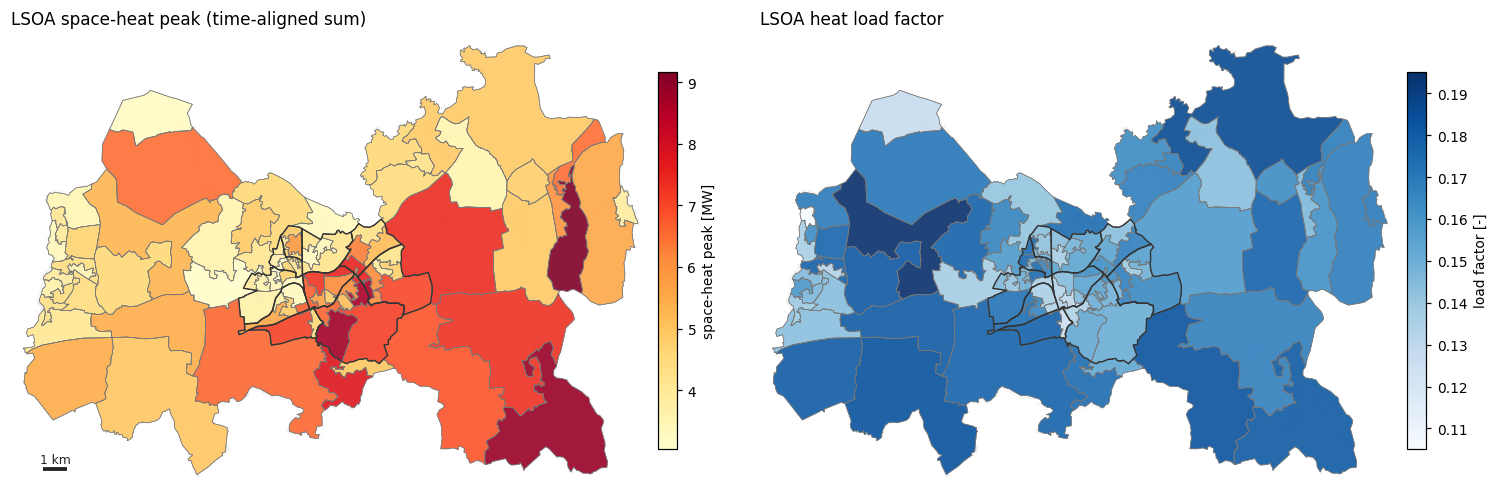

,peak_kW,peak_hour,mean_kW,load_factor,annual_GWh
count,84.00,84.00,84.00,84.00,84.00
mean,5041.35,7.48,798.43,0.16,6.99
std,1489.63,2.00,267.90,0.02,2.35
min,3053.56,7.00,406.69,0.11,3.56
25%,3913.54,7.00,598.72,0.14,5.24
50%,4640.15,7.00,745.33,0.16,6.53
75%,6011.04,7.00,952.80,0.17,8.35
max,9169.81,18.00,1595.51,0.20,13.98


In [10]:
# the same fan at LSOA level: peak-to-mean and the household-driven spread per LSOA (saved for the atlas)
lsoa_area = dw.groupby(["LSOA", "construction_sa", "size_class"])["floor_area_final"].sum()
rows = []
for lsoa, sub in lsoa_area.groupby(level=0):
    sel = {(g[1], g[2]): a for g, a in sub.items()}
    p = stock_profile(sel) * 1000
    s = profiles.peak_stats(p, idx); rows.append({"LSOA": lsoa, "peak_kW": s["peak_kW"], "peak_hour": s["peak_hour"], "mean_kW": s["mean_kW"], "load_factor": s["load_factor"], "annual_GWh": p.sum() / 1e6})
lp = pd.DataFrame(rows).set_index("LSOA"); lp.to_csv(UBEM_OUT / "09_lsoa_heat_peaks.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
maps.base_map(axes[0], L, extent="borough", show_nonres=False); maps.lsoa_map(axes[0], L, lp["peak_kW"] / 1000, cmap=maps.SEQ, label="space-heat peak [MW]"); maps.finish(axes[0], L, title="LSOA space-heat peak (time-aligned sum)", labels=False)
maps.base_map(axes[1], L, extent="borough", show_nonres=False); maps.lsoa_map(axes[1], L, lp["load_factor"], cmap=maps.SEQ_BLUE, label="load factor [-]"); maps.finish(axes[1], L, title="LSOA heat load factor", labels=False, bar=False)
plt.tight_layout(); fig.savefig(FIG_UBEM / "09_lsoa_peaks_map.png", bbox_inches="tight"); plt.show()
lp.describe().round(2)

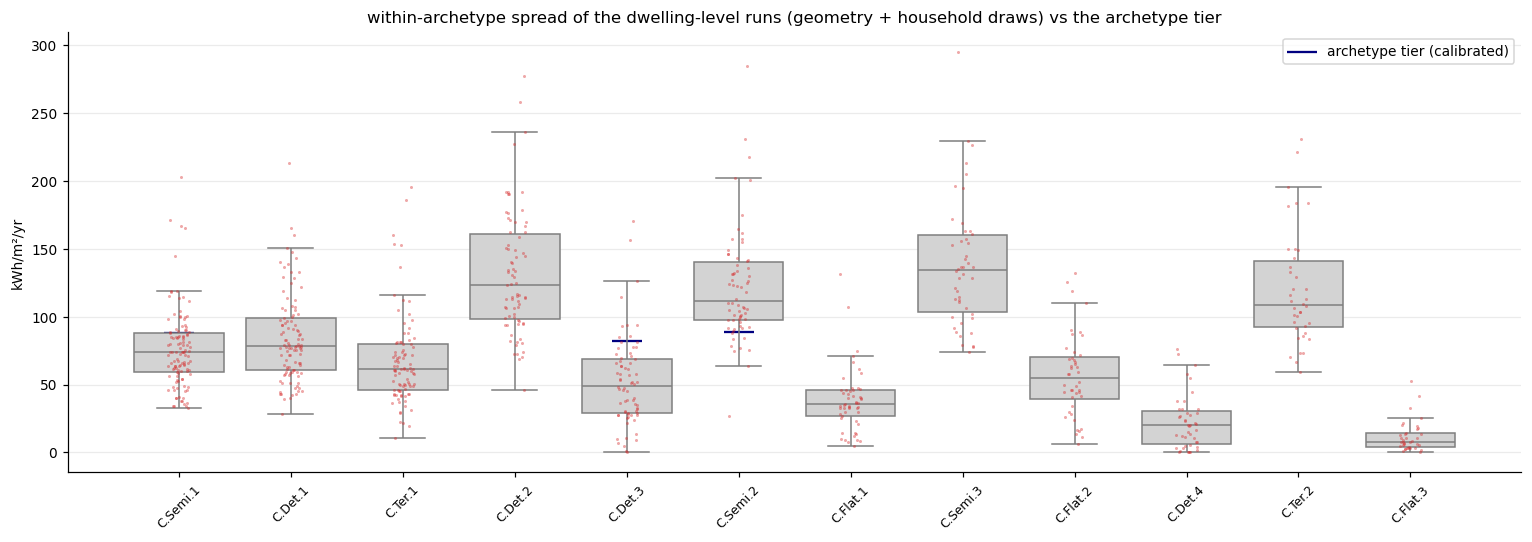

In [11]:
# within-archetype spread from the dwelling-level sample run (notebook 08), if present
f = UBEM_OUT / "08_stock_sample_joined.parquet"
if f.exists():
    smp = pd.read_parquet(f); ok = smp[smp["status"] == "ok"]
    top = ok["construction_sa"].value_counts().index[:12]
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=ok[ok["construction_sa"].isin(top)], x="construction_sa", y="Q_H_kWh_m2", order=top, showfliers=False, color="lightgrey", ax=ax)
    sns.stripplot(data=ok[ok["construction_sa"].isin(top)], x="construction_sa", y="Q_H_kWh_m2", order=top, size=2, alpha=0.4, color="tab:red", ax=ax)
    tier = inten_cal.reset_index().groupby("construction_sa")["Q_H_kWh_m2"].mean()
    ax.scatter(range(len(top)), tier.reindex(top) * post["weather_scale"], marker="_", s=400, color="navy", label="archetype tier (calibrated)")
    ax.set_xlabel(""); ax.set_ylabel("kWh/m²/yr"); ax.set_title("within-archetype spread of the dwelling-level runs (geometry + household draws) vs the archetype tier"); ax.legend(); ax.tick_params(axis="x", rotation=45, labelsize=8)
    plt.tight_layout(); fig.savefig(FIG_UBEM / "09_within_archetype_spread.png", bbox_inches="tight"); plt.show()
    spread = ok.groupby("construction_sa")["Q_H_kWh_m2"].agg(["count", "median", "std"]).join(tier.rename("tier_kWh_m2"))
    spread["cv"] = spread["std"] / spread["median"]; spread.round(2).sort_values("count", ascending=False).head(15)
else:
    print("no dwelling-level sample (run notebook 08 first)")

## What is in `outputs/ubem/`

* `09_lsoa_atlas.csv` — per LSOA: modelled vs DESNZ gas / electricity, NMBE, intensity, heating mix, totals;
* `09_validation_table.csv` — in-sample, out-of-fold (if notebook 07 ran), evidence-vintage subsets;
* `09_representative_hourly.npz`, `09_stock_hourly_heat_MW.csv`, `09_lsoa_heat_peaks.csv` — the demand curves;
* figures `09_atlas_*.png`, `09_validation_scatter.png`, `09_demand_curves.png`, `09_lsoa_peaks_map.png`, `09_within_archetype_spread.png`.